In [1]:
from pathlib import Path
import gzip
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns

from pprint import pprint

In [2]:
import math


def prop3_thresholds(*, n_ell, sigma_ell, T_ell, n_h, sigma_h, T_h, epsilon_ell, K, F_total):
    """
    Evaluate Proposition 3's ambiguity thresholds (eps_h_minus, eps_h_plus, eps_h_bar) for a
    two-type stylized model with the given aggregate parameters. See
    notebooks/check_exp_7_conditions.ipynb for the derivation notes; kept here too so this
    notebook can compute thresholds directly from the actual recorded run parameters
    (het_costs, farmer quantities) rather than re-deriving them from a freshly loaded instance.

    eps_h_minus/eps_h_plus bound the inefficient-matching interval in the n_h+eps_h <= K
    regime (cases ii-iii, root of EC3); eps_h_bar is the single threshold in the
    n_h+eps_h > K regime (cases iv-v, EC4). None means that threshold's interval is empty
    for these parameters; sigma_h <= sigma_ell means case (i) applies (no interval at all).
    """
    out = {
        "eps_h_minus": None,
        "eps_h_plus": None,
        "eps_h_bar": None,
        "regime_cutoff": K - n_h,
        "sigma_h_le_sigma_ell": sigma_h <= sigma_ell,
    }
    if sigma_h <= sigma_ell or T_h <= 0 or T_ell <= 0:
        return out

    e_ell = sigma_ell / (n_ell + epsilon_ell)

    # regime n_h + eps_h <= K: cases (ii)-(iii), roots of (EC3)
    M = T_ell * n_ell / T_h
    ratio = sigma_h / sigma_ell
    if ratio > 1:
        sqrt_term = math.sqrt(ratio) - math.sqrt(ratio - 1)
        eps_ell_u = M * sqrt_term**2 - n_ell
        out["eps_ell_u"] = eps_ell_u
        if epsilon_ell < eps_ell_u:
            b = -(M + n_ell + epsilon_ell)
            c = M * ratio * (n_ell + epsilon_ell)
            disc = b**2 - 4 * c
            if disc >= 0:
                root1 = (-b - math.sqrt(disc)) / 2
                root2 = (-b + math.sqrt(disc)) / 2
                out["eps_h_minus"], out["eps_h_plus"] = min(root1, root2), max(root1, root2)

    # regime n_h + eps_h > K: cases (iv)-(v), eps_h_bar from (EC4)
    denom = F_total * sigma_h - T_h * K * sigma_ell
    if denom > 0:
        eps_ell_s = K * (F_total - T_h * K) * sigma_ell / denom - n_ell
        out["eps_ell_s"] = eps_ell_s
        if epsilon_ell < eps_ell_s:
            cand1 = (K - n_h) + n_h * (sigma_h - sigma_ell) / (K * e_ell - sigma_ell)
            cand2 = T_ell * n_ell * sigma_h / ((F_total - T_h * K) * e_ell + T_h * sigma_ell)
            out["eps_h_bar"] = min(cand1, cand2)
        else:
            out["eps_h_bar"] = float("inf")

    return out


In [3]:
sns.set_theme(context="paper", style="ticks")

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

def currency_formatter(x, pos):
    return f"${x:.0f}"

def pp_formatter(x, pos):
    return f"{x * 100:.0f}pp"

In [4]:
root = Path("../results/exp_7")
jsons = list(root.rglob("*.json.gz"))

graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path("../data/anon_14_day_instances/2020-08-27.yaml"))

In [5]:
# load data
data = []
check = []
rhss = []
values =[]
nhs = {}
prop3_thresholds_by_instance = {}
for file in jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        aggregate_payload = json.load(f)

    instance_idx = aggregate_payload["instance_index"]

    holds = False

    for payload in aggregate_payload["runs"]:
        # pprint(payload)
        job_id = aggregate_payload["experiment_metadata"]["job_id"]
        summary = payload["summary"]

        result = summary["platform_solve_result"]["primary_result"]

        matched = set(result["selected_intermediaries"])
        treatment_ids = set(aggregate_payload["treatment_ids"])

        top_n = len(treatment_ids)

        treatment_matched = matched.intersection(treatment_ids)

        # model-side status quo quantity per intermediary, matching
        # HIST_SET_METHOD = "instance_farmers" in exp_7.py: the sum of
        # quantities of farmers assigned to that intermediary in this instance.
        farmer_quantity_by_intermediary = {}
        for farmer in summary["instance_snapshot"]["farmers"]:
            farmer_quantity_by_intermediary[farmer["intermediary_id"]] = (
                farmer_quantity_by_intermediary.get(farmer["intermediary_id"], 0.0)
                + farmer["quantity"]
            )
        nhs[instance_idx] = [
            farmer_quantity_by_intermediary.get(treatment_id, 0.0)
            for treatment_id in sorted(treatment_ids)
        ]

        # Prop 3 thresholds per treated intermediary (per_intermediary version:
        # T_h=1, using that intermediary's own recorded sigma/n; T_ell/n_ell/sigma_ell
        # aggregated over the actual control intermediaries in this instance).
        # sigma_t comes from the het_costs actually used to solve this run, not a
        # freshly-recomputed clip_het_costs, so this matches the real solve exactly.
        # Computed once per instance_idx since these don't depend on epsilon_h.
        if instance_idx not in prop3_thresholds_by_instance:
            sigma_t_all = summary["params"]["het_costs"]
            all_ids = {i["id"] for i in summary["instance_snapshot"]["intermediaries"]}
            control_ids = all_ids - treatment_ids
            K = summary["instance_snapshot"]["constants"]["truck_capacity_tons"]
            F_total = sum(farmer_quantity_by_intermediary.values())
            n_ell = sum(farmer_quantity_by_intermediary.get(cid, 0.0) for cid in control_ids) / len(control_ids)
            sigma_ell = sum(sigma_t_all[cid] for cid in control_ids) / len(control_ids)

            per_intermediary = {
                treatment_id: prop3_thresholds(
                    n_ell=n_ell, sigma_ell=sigma_ell, T_ell=len(control_ids),
                    n_h=farmer_quantity_by_intermediary.get(treatment_id, 0.0),
                    sigma_h=sigma_t_all[treatment_id], T_h=1,
                    epsilon_ell=aggregate_payload["epsilon_ell"], K=K, F_total=F_total,
                )
                for treatment_id in treatment_ids
            }

            # aggregated version: collapse the whole treated group into one representative
            # high type (T_h = top_n, sigma_h/n_h averaged over the treated group) --
            # one threshold shared by all treated intermediaries in this instance, rather
            # than one per intermediary.
            n_h_agg = sum(farmer_quantity_by_intermediary.get(tid, 0.0) for tid in treatment_ids) / len(treatment_ids)
            sigma_h_agg = sum(sigma_t_all[tid] for tid in treatment_ids) / len(treatment_ids)
            aggregated = prop3_thresholds(
                n_ell=n_ell, sigma_ell=sigma_ell, T_ell=len(control_ids),
                n_h=n_h_agg, sigma_h=sigma_h_agg, T_h=len(treatment_ids),
                epsilon_ell=aggregate_payload["epsilon_ell"], K=K, F_total=F_total,
            )

            prop3_thresholds_by_instance[instance_idx] = {
                "per_intermediary": per_intermediary,
                "aggregated": aggregated,
            }

        match_rate = len(treatment_matched) / len(treatment_ids)
        epsilon_h = aggregate_payload["epsilon_h"]
        epsilon_l = aggregate_payload["epsilon_ell"]

        row = {
            "instance_idx": instance_idx,
            "job_id": job_id,
            "epsilon_h": epsilon_h,
            "epsilon_l": epsilon_l,
            "match_rate": match_rate,
            "top_n": top_n,
            "nhs": tuple(nhs[instance_idx]),
            "treatment_ids": tuple(sorted(treatment_ids)),
            "matched_ids": tuple(sorted(treatment_matched)),
        }

        data.append(row)

df = pd.DataFrame(data)
# print(np.quantile(rhss, [0.5, 0.7, 0.8, 0.9, 0.95]))


In [6]:
df.query("instance_idx == 6").sort_values(by="epsilon_h")

,instance_idx,job_id,epsilon_h,epsilon_l,match_rate,top_n,nhs,treatment_ids,matched_ids
3,6,48,0.0,0.5,0.000000,3,"(8.7, 6.300000000000001, 4.800000000000001)","(competent_mayer, elegant_gagarin, vigorous_mc...",()
12,6,49,1.0,0.5,0.000000,3,"(8.7, 6.300000000000001, 4.800000000000001)","(competent_mayer, elegant_gagarin, vigorous_mc...",()
72,6,50,2.0,0.5,0.333333,3,"(8.7, 6.300000000000001, 4.800000000000001)","(competent_mayer, elegant_gagarin, vigorous_mc...","(competent_mayer,)"
79,6,51,3.0,0.5,0.333333,3,"(8.7, 6.300000000000001, 4.800000000000001)","(competent_mayer, elegant_gagarin, vigorous_mc...","(competent_mayer,)"
39,6,52,4.0,0.5,0.333333,3,"(8.7, 6.300000000000001, 4.800000000000001)","(competent_mayer, elegant_gagarin, vigorous_mc...","(competent_mayer,)"
35,6,53,5.0,0.5,0.666667,3,"(8.7, 6.300000000000001, 4.800000000000001)","(competent_mayer, elegant_gagarin, vigorous_mc...","(competent_mayer, elegant_gagarin)"
34,6,54,6.0,0.5,1.000000,3,"(8.7, 6.300000000000001, 4.800000000000001)","(competent_mayer, elegant_gagarin, vigorous_mc...","(competent_mayer, elegant_gagarin, vigorous_mc..."
40,6,55,7.0,0.5,1.000000,3,"(8.7, 6.300000000000001, 4.800000000000001)","(competent_mayer, elegant_gagarin, vigorous_mc...","(competent_mayer, elegant_gagarin, vigorous_mc..."


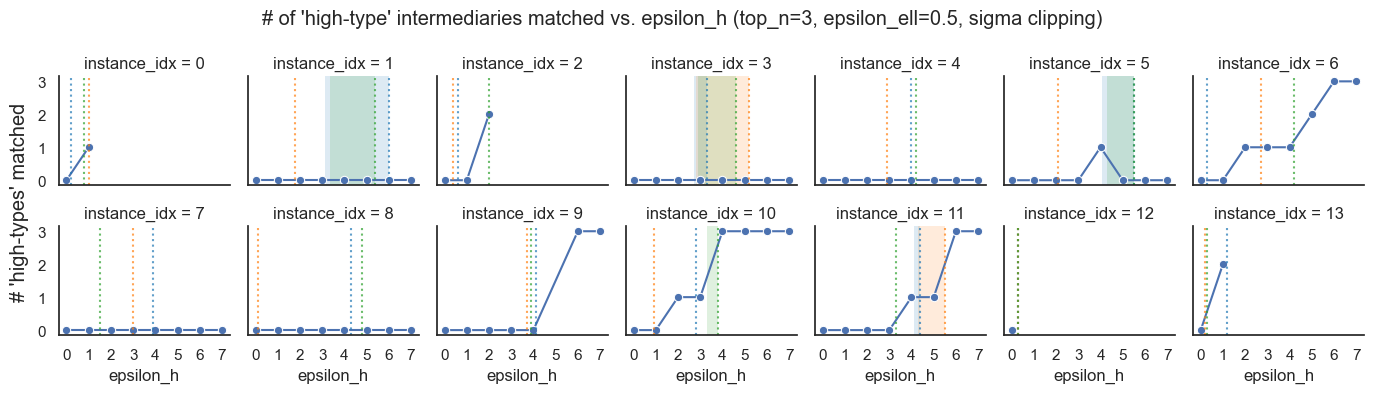

In [7]:
K = 9

sns.set_theme(context="notebook", style="white")

plot_df = df.query(f"top_n == {3}").assign(n_matched=lambda d: d["match_rate"] * d["top_n"])

g = sns.relplot(
    data=plot_df,
    x="epsilon_h",
    y="n_matched",
    col="instance_idx",
    col_wrap=7,
    kind="line",
    height=2,
    aspect=1,
    markers=True,
    marker="o"
)
intermediary_colors = sns.color_palette("tab10", n_colors=3)

for ax, instance_idx in zip(g.axes.flat, sorted(plot_df.instance_idx.unique())):
    instance_df = plot_df.query("instance_idx == @instance_idx").sort_values("epsilon_h")
    treatment_ids = instance_df["treatment_ids"].iloc[0]
    n_hs = nhs[instance_idx]
    thresholds = prop3_thresholds_by_instance[instance_idx]

    for rank, (treatment_id, n_h) in enumerate(zip(treatment_ids, n_hs)):
        color = intermediary_colors[rank]

        # per-intermediary saturation threshold: K - n_h
        naive_threshold = K - n_h
        ax.axvline(x=naive_threshold, color=color, linestyle=":", alpha=0.7)

        # (eps_h_minus, eps_h_plus): the cases (ii)-(iii) inefficient interval, only
        # valid where n_h+eps_h <= K, i.e. eps_h <= regime_cutoff (== naive_threshold
        # above). Clip to that range and skip entirely if the interval starts beyond
        # it (no overlap, so this regime never actually applies for these parameters).
        eps_h_minus = thresholds["per_intermediary"][treatment_id]["eps_h_minus"]
        eps_h_plus = thresholds["per_intermediary"][treatment_id]["eps_h_plus"]
        regime_cutoff = thresholds["per_intermediary"][treatment_id]["regime_cutoff"]
        if eps_h_minus is not None and eps_h_minus < regime_cutoff:
            ax.axvspan(
                max(0.0, eps_h_minus), min(eps_h_plus, regime_cutoff),
                color=color, alpha=0.15, linewidth=0,
            )

    ax.set_xticks(range(8))
    ax.set_yticks(range(4))

g.set_axis_labels("epsilon_h", "")
g.figure.supylabel("# 'high-types' matched")
g.figure.suptitle(f"# of 'high-type' intermediaries matched vs. epsilon_h (top_n={3}, epsilon_ell=0.5, sigma clipping)")
plt.tight_layout()
plt.savefig("../figures/exp_7/eps_sweep_match_rates.png")
plt.show()
